In [6]:
from pathlib import Path
import sys
import torch 

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0,str(PROJECT_ROOT))

from fullmodeltrain.instancepipeline import get_data_loaders
from fullmodeltrain.finalfulltrain import EarthquakeCNN, evaluate_metrics

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_path = PROJECT_ROOT / "fullmodeltrain" / "data" / "best_model_full.pth"

checkpoint = torch.load(checkpoint_path, map_location=device)
model = EarthquakeCNN().to(device)

model.load_state_dict(checkpoint["model_state_dict"])

model.eval()




EarthquakeCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv1d(3, 16, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (3): Sequential(
      (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (4): Sequential(
      (0): Conv1d(128, 256, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, str

In [9]:
import torch
import numpy as np
import pandas as pd
TARGET_MEAN = 2.28802128052746
train_loader, val_loader, test_loader = get_data_loaders()
all_predictions = []
all_targets = []
model.eval()
with torch.no_grad():
    for waveforms,magnitudes in test_loader:
        waveforms,magnitudes = waveforms.to(device), magnitudes.to(device)
        predictions = model(waveforms).squeeze(-1) 
        magnitudes = magnitudes + 2.28802128052746
        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(magnitudes.cpu().numpy())
results = pd.DataFrame({
    "true_magnitude": np.array(all_targets),
    "predicted_magnitude": np.array(all_predictions)
})


In [8]:
print(results[["true_magnitude", "predicted_magnitude"]].mean())

true_magnitude         4.432577
predicted_magnitude    1.975305
dtype: float32


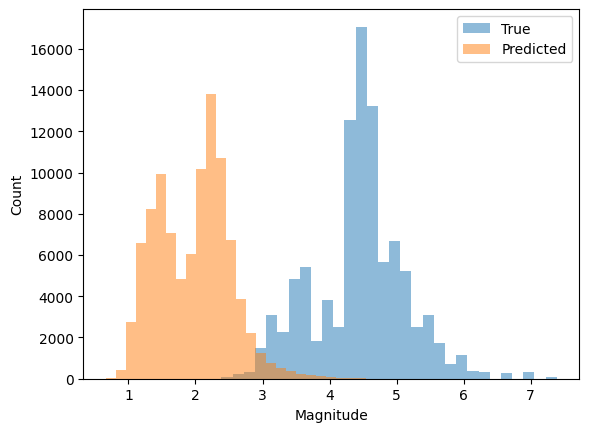

In [4]:
import matplotlib.pyplot as plt

plt.hist(results["true_magnitude"], bins=30, alpha=0.5, label="True")
plt.hist(results["predicted_magnitude"], bins=30, alpha=0.5, label="Predicted")
plt.xlabel("Magnitude")
plt.ylabel("Count")
plt.legend()
plt.show()

In [23]:
results["error"] = (
    results["predicted_magnitude"]
    - results["true_magnitude"]
)

results["bin"] = pd.cut(
    results["true_magnitude"],
    bins=[0, 1, 2, 3, 4, 5, 6]
)

results.groupby("bin", observed=True)["error"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
bin,,,
"(0, 1]",7458,0.736606,0.678717
"(1, 2]",31012,0.303790,0.271832
"(2, 3]",50408,-0.067517,-0.045833
"(3, 4]",7422,-0.655472,-0.634762
"(4, 5]",602,-1.552471,-1.571690
"(5, 6]",91,-2.150716,-2.071690


In [24]:
print((results["true_magnitude"] > 2).count())
print((results["true_magnitude"] < 2).count())

96993
96993


In [1]:
from pathlib import Path
import sys
import torch 

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0,str(PROJECT_ROOT))

from fullmodeltrain.instancepipeline import get_data_loaders
from fullmodeltrain.finalfulltrain import EarthquakeCNN, evaluate_metrics

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_path2 = PROJECT_ROOT / "fullmodeltrain" / "data" / "best_model_fullnn.pth"

checkpoint2 = torch.load(checkpoint_path2, map_location=device)
model2 = EarthquakeCNN().to(device)

model2.load_state_dict(checkpoint2["model_state_dict"])

model2.eval()

EarthquakeCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv1d(3, 16, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (3): Sequential(
      (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (4): Sequential(
      (0): Conv1d(128, 256, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, str

In [11]:
all_predictions = []
all_targets = []

model2.eval()
TARGET_MEAN = 2.28802128052746
with torch.no_grad():
    for waveforms, magnitudes in val_loader:
        waveforms = waveforms.to(device)
        magnitudes = magnitudes.to(device)

        # model predicts centered magnitude
        predictions = model2(waveforms).squeeze(-1)

        # convert BOTH back to actual magnitude
        predictions = predictions + TARGET_MEAN
        magnitudes = magnitudes + TARGET_MEAN

        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(magnitudes.cpu().numpy())

results2 = pd.DataFrame({
    "true_magnitude": all_targets,
    "predicted_magnitude": all_predictions
})

In [12]:
print("true:", results2["true_magnitude"].min(), results2["true_magnitude"].max())
print("pred:", results2["predicted_magnitude"].min(), results2["predicted_magnitude"].max())
print("mean true:", results2["true_magnitude"].mean())
print("mean pred:", results2["predicted_magnitude"].mean())

true: 0.099999905 5.1
pred: 1.0350431 15.92526
mean true: 2.1445558
mean pred: 2.1257663


In [14]:
print("True min/max:",
      results2["true_magnitude"].min(),
      results2["true_magnitude"].max())

print("Pred min/max:",
      results2["predicted_magnitude"].min(),
      results2["predicted_magnitude"].max())

True min/max: 0.099999905 5.1
Pred min/max: 1.0350431 15.92526


In [15]:
print((results2["predicted_magnitude"] > 6).sum())

11


In [16]:
results2[
    results2["predicted_magnitude"] > 6
].sort_values("predicted_magnitude", ascending=False)

,true_magnitude,predicted_magnitude
10345,1.9,15.925260
57264,2.4,15.316999
83949,2.0,10.695432
64957,4.6,9.779158
2449,3.4,8.470053
7356,2.7,7.911631
20007,3.2,7.774384
58500,4.3,7.581277
5401,1.9,6.961603
13479,2.6,6.843710


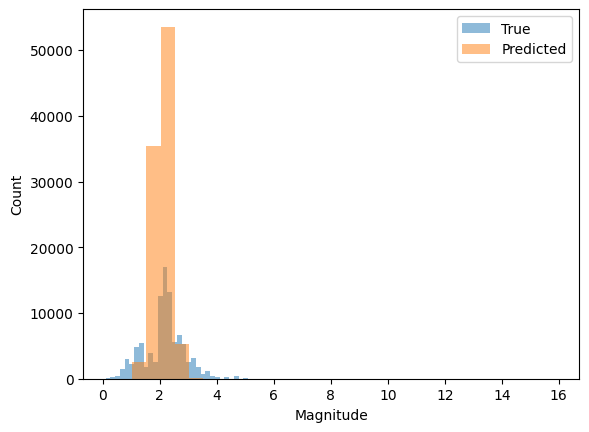

In [13]:
import matplotlib.pyplot as plt

plt.hist(results2["true_magnitude"], bins=30, alpha=0.5, label="True")
plt.hist(results2["predicted_magnitude"], bins=30, alpha=0.5, label="Predicted")
plt.xlabel("Magnitude")

plt.ylabel("Count")
plt.legend()
plt.show()

In [5]:
print("True min/max:", results["true_magnitude"].min(), results["true_magnitude"].max())
print("Pred min/max:", results["predicted_magnitude"].min(), results["predicted_magnitude"].max())

NameError: name 'results' is not defined

In [17]:
idx = 10345

waveform, target = val_loader.dataset[idx]

print("target centered:", target.item())
print("target actual:", (target + TARGET_MEAN).item())
print("shape:", waveform.shape)
print("min:", waveform.min().item())
print("max:", waveform.max().item())
print("abs max:", waveform.abs().max().item())
print("mean:", waveform.mean().item())
print("std:", waveform.std().item())

target centered: -0.3880213499069214
target actual: 1.899999976158142
shape: torch.Size([3, 300])
min: -11678.0
max: 5703319.0
abs max: 5703319.0
mean: 13751.654296875
std: 254251.078125


In [18]:
idx = 100

waveform, target = val_loader.dataset[idx]

print("target actual:", (target + TARGET_MEAN).item())
print("min:", waveform.min().item())
print("max:", waveform.max().item())
print("abs max:", waveform.abs().max().item())
print("mean:", waveform.mean().item())
print("std:", waveform.std().item())

target actual: 3.299999952316284
min: -7914.0
max: 12927.0
abs max: 12927.0
mean: 465.34332275390625
std: 3071.751708984375


In [36]:
results2["error"] = (
    results["predicted_magnitude"]
    - results["true_magnitude"]
)

results2["bin"] = pd.cut(
    results["true_magnitude"],
    bins=[0, 1, 2, 3, 4, 5, 6]
)

results2.groupby("bin", observed=True)["error"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
bin,,,
"(0, 1]",7458,0.736606,0.678717
"(1, 2]",31012,0.303790,0.271832
"(2, 3]",50408,-0.067517,-0.045833
"(3, 4]",7422,-0.655472,-0.634762
"(4, 5]",602,-1.552471,-1.571690
"(5, 6]",91,-2.150716,-2.071690
